In [267]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from macrohet import visualise, colours
from tqdm.auto import tqdm
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import gridspec
from tqdm import tqdm
import os
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch
import webbrowser

from PIL import Image
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.size'] = 14
visualise.set_plotting_defaults()
expanded_piyg = colours.expanded_piyg
# Conversion factor
meters_per_pixel = 1.4949402023919043E-07  # Micrometers per pixel
micrometers_per_pixel = meters_per_pixel*1E6 # Micrometers per pixel

Helvetica not found. Using Nimbus Sans font.
Default plotting aesthetic loaded.


In [268]:
def replace_ytick_labels(ax, old_label, new_label):
    """
    Replace y-axis tick labels in a given matplotlib Axes object.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axes on which to replace y-tick labels.
    old_label (str): The label to be replaced.
    new_label (str): The new label to replace the old label with.
    """
    # Get current y-tick labels
    yticks = ax.get_yticks()
    yticklabels = [label.get_text() for label in ax.get_yticklabels()]

    # Replace the old label with the new label
    yticklabels = [new_label if label == old_label else label for label in yticklabels]

    # Set the new y-tick labels
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

In [269]:
# df = pd.read_pickle('/Volumes/OPERA2/Nathan/macrohet_syno/results/dfs/sc_df.pkl')
df = pd.read_pickle('/mnt/SYNO/macrohet_syno/results/dfs/sc_df.pkl')


In [270]:
df

,ID,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,...,Edge Status,Uptake,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2
0,1.3.2.ND0002,0.0,0.0,0.0,4649.351562,2080.574775,NaN,False,False,107.845200,...,False,False,NaN,NaN,NaN,NaN,None,None,None,1.0
1,1.3.2.ND0002,0.5,0.0,0.0,4973.001953,2080.574775,NaN,False,False,113.264671,...,False,False,0.0,NaN,NaN,NaN,None,None,None,1.0
2,1.3.2.ND0002,1.0,0.0,0.0,4687.857910,2080.574775,NaN,False,False,116.562256,...,False,False,0.0,NaN,NaN,NaN,None,None,None,1.0
3,1.3.2.ND0002,1.5,0.0,0.0,4209.064453,2080.574775,NaN,False,False,111.890106,...,False,False,0.0,NaN,NaN,NaN,None,None,None,1.0
4,1.3.2.ND0002,2.0,0.0,0.0,4061.855225,2080.574775,False,False,False,114.113556,...,False,False,0.0,NaN,0.0,0.0,None,None,None,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1914150,9998.4.6.ND0004,59.5,0.0,NaN,261.387613,NaN,False,False,False,1034.000000,...,False,NaN,NaN,0.0,58.5,0.0,None,None,None,-1.02
1914151,9998.4.6.ND0004,60.0,0.0,NaN,275.109568,NaN,False,False,False,972.000000,...,False,NaN,NaN,0.0,59.0,0.0,None,None,None,-1.02
1914152,9998.4.6.ND0004,60.5,0.0,NaN,404.484815,NaN,False,False,False,948.000000,...,False,NaN,NaN,0.0,59.5,0.0,None,None,None,-1.02
1914153,9998.4.6.ND0004,61.0,0.0,NaN,297.055758,NaN,NaN,False,False,874.000000,...,False,NaN,NaN,0.0,NaN,NaN,None,None,None,-1.02


### Params

In [271]:
### set plotting parameters
# Input figure size in millimeters
width_mm = 280  # for example, 180 mm
height_mm = 100  # for example, 80 mm
# Convert millimeters to inches (1 inch = 25.4 mm)
width_in = width_mm / 25.4
height_in = height_mm / 25.4

### set biological parameters
# Step 1: Bin the Doubling Times into categories
bins = [0, 16, 24, float('inf')]  # Define the bins: <20, 20-24, >24
labels = ['Fast', 'Normal', 'Slow']  # Labels for each bin
# Define the desired order with CTRL at the top
strain_order = ['CTRL', 'PZA', 'INH', 'RIF']

# F1 interactive

In [272]:
# Filter the subset DataFrame based on conditions
IDs = df[
    (df['Compound'] == 'CTRL') &
    (df['Strain'] == 'WT') &
    (df['mtb_origin'] != 'Junk') &
    (df['Infection Status'] == True)
].ID.unique()

# Ensure that df contains only rows with IDs present in the subset_df
subset_df = df[df['ID'].isin(IDs)]

100%|███████████████████████████████████████████| 1154/1154 [00:14<00:00, 82.37it/s]


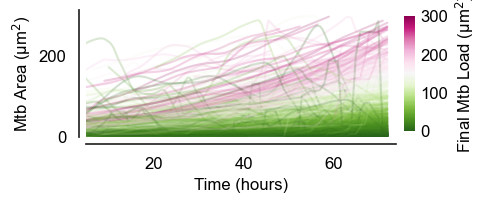

In [273]:
# Import necessary modules
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# Constants for figure size
fig_width_mm = 122.365
fig_width_inch = fig_width_mm / 25.4
fig_height_mm = 42
fig_height_inch = fig_height_mm / 25.4

# Define the colormap using 'PiYG_r'
cmap = plt.get_cmap('PiYG_r')

# Create the plot
plt.figure(figsize=(fig_width_inch, fig_height_inch))



for ID in tqdm(subset_df['ID'].unique(), total=len(subset_df['ID'].unique())):
    sc_df = subset_df[subset_df['ID'] == ID]
    time_model = sc_df['Time Model (hours)'].dropna().values
    population_model = sc_df['Mtb Area Model (µm)'].dropna().values

    # Filter based on max population value
    max_value = np.nanmax(population_model)
    if max_value < 4 or max_value > 300:
        continue

    # Calculate the color value based on the third-last value of the population model
    colour_value = population_model[-1]

    # Normalize the average value to the range [0, 1] for the colormap
    norm = mpl.colors.Normalize(vmin=0, vmax=300)
    color = cmap(norm(colour_value))

    # Plot the data with the corresponding color
    plt.plot(time_model, population_model, color=color, alpha=0.2)

# Set labels and limits
plt.xlabel('Time (hours)')
plt.ylabel('Mtb Area (µm$^2$)')
plt.ylim(bottom=0)
sns.despine(offset=5)
plt.xlim(5, 74)

# Create a wider color bar to the right of the plot
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for color bar
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', pad=0.02, aspect=10, shrink=0.9)  # Adjust width with aspect and shrink
cbar.set_label('Final Mtb Load (µm$^2$)')
cbar.ax.tick_params(size=0)

# Remove the black border (outline) of the color bar
cbar.outline.set_visible(False)


### Generate single-cell snapshots from mp4s 

Need to ensure that the time frame corresponds to the correct mtb measurement

In [86]:
# Iterate over unique IDs
for ID, ID_df in tqdm(subset_df.groupby('ID'), desc = 'iterating over cells'):
    glimpse_fn = f'/mnt/SYNO/macrohet_syno/results/glimpse_store/glimpses/{ID}.mp4'
    output_dir = f'/mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/{ID}'
    os.makedirs(output_dir, exist_ok=True)

    # Ensure the time column is sorted
    ID_df = ID_df.sort_values('Time (hours)').reset_index(drop=True)

    # Create a complete range of time values
    full_time_range = np.arange(ID_df['Time (hours)'].min(), ID_df['Time (hours)'].max() + 1)

    # Reindex the DataFrame to fill missing time values
    ID_df = ID_df.set_index('Time (hours)').reindex(full_time_range).reset_index()
    ID_df.rename(columns={'index': 'Time (hours)'}, inplace=True)

    # Open the video file
    cap = cv2.VideoCapture(glimpse_fn)
    if not cap.isOpened():
        print(f"Error: Could not open video file {glimpse_fn}")
        continue

    # Iterate over the reindexed DataFrame
    previous_frame = None  # To store the last valid frame
    video_frame_idx = 0  # Actual frame index in the video

    for i, row in ID_df.iterrows():
        frame_filename = os.path.join(output_dir, f'frame_{int(row["Time (hours)"]):03d}.png')

        if pd.isna(row['ID']):  # If the row contains NaN, use the previous frame
            print(f"Missing frame at time {row['Time (hours)']}, copying the previous frame.")
            if previous_frame is not None:
                cv2.imwrite(frame_filename, previous_frame)
        else:
            # Set the video frame position and read the frame
            cap.set(cv2.CAP_PROP_POS_FRAMES, video_frame_idx)
            ret, frame = cap.read()
            if not ret:  # Break if video reading fails
                print(f"Warning: Could not read frame {video_frame_idx} from video {glimpse_fn}")
                break

            # Save the current frame and update the previous frame
            cv2.imwrite(frame_filename, frame)
            previous_frame = frame  # Update the last valid frame

            # Increment the video frame index
            video_frame_idx += 1

    cap.release()
    print(f"Processed video for ID {ID}, frames saved to {output_dir}.")



iterating over cells:   0%|          | 0/1154 [00:00<?, ?it/s]

Missing frame at time 16.0, copying the previous frame.
Missing frame at time 41.0, copying the previous frame.
Processed video for ID 1.3.5.PS0000, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1.3.5.PS0000.
Processed video for ID 1.6.5.PS0000, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1.6.5.PS0000.
Processed video for ID 1007.4.3.ND0002, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1007.4.3.ND0002.
Missing frame at time 75.0, copying the previous frame.
Processed video for ID 1011.3.4.ND0002, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1011.3.4.ND0002.
Processed video for ID 1024.4.5.PS0000, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1024.4.5.PS0000.
Processed video for ID 1027.6.5.PS0000, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1027.6.5.PS0000.
Missing frame at time 25.5, copying the 

In [274]:
# add image links
subset_df['Image Link'] = subset_df['Image Link'] = subset_df.apply(
    # lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/{row['ID']}_t{row['Time (hours)']}.png",
    # lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/glimpse_frames/4108.4.3.ND0003/frame_067.png",
    lambda row: f"https://macrohet.s3.eu-west-2.amazonaws.com/macrohet.glimpses/glimpse_frames/{row['ID']}/frame_{int(row['Time (hours)']):03d}.png",
    axis=1
)

In [100]:
subset_df['Image Link'].iloc[0]

'https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/glimpse_frames/4108.4.3.ND0003/frame_067.png'

In [275]:
from dash import Dash, dcc, html
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Prepare data for Plotly
traces = []
cmap = plt.get_cmap('PiYG_r')
norm = mpl.colors.Normalize(vmin=0, vmax=300)

for ID in tqdm(subset_df['ID'].unique()):
    sc_df = subset_df[subset_df['ID'] == ID]
    time_model = sc_df['Time Model (hours)'].dropna().values - min(sc_df['Time Model (hours)'].dropna().values)
    population_model = sc_df['Mtb Area Model (µm)'].dropna().values
    compound = sc_df['Compound'].iloc[0]
    concentration = sc_df['Concentration'].iloc[0] if not 'EC0' else 'N/A'
    # Filter based on max population value
    max_value = np.nanmax(population_model)
    if max_value < 4 or max_value > 300:
        continue

    # Calculate the color value based on the final value of the population model
    colour_value = population_model[-1]
    color = f"rgba{tuple((np.array(cmap(norm(colour_value))) * 255).astype(int))}"

    # Add a trace for each line
    traces.append(go.Scatter(
        x=time_model,
        y=population_model,
        mode='lines',
        line=dict(color=color, width=4),
        name=f"ID: {ID}",  # Line name for identification (optional)
        hoverinfo="text",
        customdata=sc_df['Image Link'],  # Pass image links via custom data
        text=[f"<b>ID:</b> {ID}<br><b>Time:</b> {t:.2f} hours<br><b>Mtb Area:</b> {p:.2f} µm²"
              for t, p in zip(time_model, population_model)],
        opacity=0.6,
        showlegend=False
    ))


100%|███████████████████████████████████████████| 1154/1154 [00:14<00:00, 79.40it/s]


In [ ]:
# Create a special trace just for the colorbar
# This trace has no visible points but controls the colorbar appearance
colorbar_trace = go.Scatter(
    x=[None],  # Empty data since we only want the colorbar
    y=[None],
    mode='markers',
    marker=dict(
        size=0,  # Make markers invisible
        cmax=300,  # Maximum value for color scale
        cmin=0,   # Minimum value for color scale
        colorbar=dict(
            thickness=15,    # Width of the colorbar
            len=0.9,        # Length of colorbar as fraction of plot height
            outlinewidth=0,  # Remove border around colorbar
            tickfont=dict(family="Helvetica", size=16),  # Style the tick labels
            title=dict(
                text="\nFinal Mtb Load (µm²)",  # Colorbar title with units
                side='right',                   # Position title on right side
                font=dict(family="Helvetica", size=16),
            ),
            xpad=10,  # Add padding between plot and colorbar
        ),
        colorscale="PiYG"  # Use PiYG (Pink to Green) color palette
    ),
    hoverinfo='none',    # Disable hover effects
    showlegend=False     # Hide from legend
)

# Combine the colorbar trace with our existing data traces
fig = go.Figure(data=traces + [colorbar_trace])
fig.update_traces(visible=True)  # Ensure all traces are visible

# Configure the overall plot layout
fig.update_layout(
    # X-axis settings
    xaxis=dict( 
        title=dict(text="Time (hours)"),
        gridcolor='rgba(200,200,200,0.3)',  # Light grey grid
        showline=False,   # Hide axis line
        zeroline=False,   # Hide zero line
        showgrid=False,   # Hide grid
        range=[-2, 70],   # Set axis range with padding
    ),
    
    # Y-axis settings
    yaxis=dict(
        title=dict(text="Mtb Area (µm²)"),
        gridcolor='rgba(200,200,200,0.3)',
        showline=False,
        showgrid=False,
        zeroline=False,
        range=[-30, 300],
    ),
    
    # Add custom axis lines offset from the plot
    shapes=[
        # Y-axis line
        dict(
            type="line",
            xref="x", yref="y",
            x0=-1, x1=-1,     # Position slightly left of data
            y0=0, y1=600,     # Extend beyond data range
            line=dict(color="black", width=2)
        ),
        # X-axis line
        dict(
            type="line",
            xref="x", yref="y",
            x0=0, x1=70,      # Span full width
            y0=-20, y1=-20,   # Position slightly below data
            line=dict(color="black", width=2)
        )
    ],
    
    # General plot settings
    hovermode="closest",         # Show hover info for nearest point
    template="plotly_white",     # Use white background template
    autosize=True,              # Enable responsive sizing
    height=None,                # Allow height to adjust automatically
    width=None,                 # Allow width to adjust automatically
    
    # Font settings
    font=dict(
        family="Helvetica",
        size=16
    ),
    
    # Margin settings
    margin=dict(
        l=36,    # Left margin
        r=18,    # Right margin
        t=36,    # Top margin
        b=36,    # Bottom margin
        pad=6    # Internal padding
    )
)

### the rest of F1

In [163]:
# Save the plot to an HTML file with added video functionality
output_file = "../interactive_plots/time_series.html"
# Create the HTML template with Plotly figure and hover functionality
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        .container {{
            width: 50%;
            margin: 0 auto;
        }}
        .header-image {{
            width: 100%;
            height: auto;
            margin-bottom: 20px;
        }}
        #plot {{
            width: 100%;
            height: 50vh;
        }}
    </style>
</head>
<body>
    <div class="container">
        <img src="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/Figure_1_crop.png" alt="Header Image" class="header-image">
        <div id="plot"></div>
    </div>
    <script>
        // Load the Plotly figure
        const figure = {fig.to_json()};
        
        // Render the plot
        Plotly.newPlot('plot', figure.data, figure.layout);
        
        // Add hover event listener
        document.getElementById('plot').on('plotly_hover', function(eventData) {{
            const point = eventData.points[0];
            const imageLink = point.customdata;
            
            // Extract the image link
            if (imageLink) {{
                // Append the image to the hover tooltip
                const hoverContent = document.createElement('div');
                hoverContent.style.position = 'absolute';
                hoverContent.style.backgroundColor = 'white';
                hoverContent.style.border = '2px solid white';
                hoverContent.style.padding = '5px';
                hoverContent.style.zIndex = 1000;
                hoverContent.style.display = 'flex';
                hoverContent.style.alignItems = 'center';
                hoverContent.style.gap = '10px'; // Space between the image and text
                
                hoverContent.innerHTML = `<img src="${{imageLink}}" style="width: 300px; height: auto;">`;
                document.body.appendChild(hoverContent);
                
                // Position the hover content to the left of the mouse
                const hoverWidth = hoverContent.offsetWidth;
                hoverContent.style.left = `${{eventData.event.clientX - hoverWidth - 10}}px`;
                hoverContent.style.top = `${{eventData.event.clientY + 200}}px`;
                
                // Remove the hover content when the mouse leaves
                document.getElementById('plot').on('plotly_unhover', function() {{
                    hoverContent.remove();
                }});
            }}
        }});
    </script>
</body>
</html>
"""
# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)
print(f"Interactive plot with video functionality saved to {output_file}")

# After your existing code that saves the file:
webbrowser.open('file://' + os.path.realpath(output_file))

Interactive plot with video functionality saved to ../interactive_plots/time_series.html


True

### With other larger images

In [299]:
# Save the plot to an HTML file with added video functionality
output_file = "../docs/figures/F1.html"
# F1.html"
# Create the HTML template with Plotly figure and hover functionality
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        .container {{
            width: 100%;
            margin: 0 auto;
        }}
        .header-image-container {{
            position: relative;
            width: 100%;
            margin-bottom: 20px;
        }}
        .header-image {{
            width: 100%;
            height: auto;
        }}
        .hover-area {{
            position: absolute;
            cursor: pointer;
            background: rgba(255, 255, 255, 0.0);
            transition: background 0.3s;
        }}
        .hover-area:hover {{
            background: rgba(255, 255, 255, 0.1);
        }}
        #plot {{
            width: 100%;
            aspect-ratio: 22/9;
        }}
        .hover-popup {{
            position: absolute;
            background-color: white;
            border: 2px solid white;
            padding: 5px;
            z-index: 1000;
            display: none;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        .modal {{
            display: none;
            position: fixed;
            top: 0;
            left: 0;
            width: 100%;
            height: 100%;
            background-color: rgba(0,0,0,0.9);
            z-index: 2000;
            overflow: hidden;
        }}
        .modal-content {{
            position: relative;
            width: 90%;
            height: 90%;
            margin: auto;
            display: flex;
            justify-content: center;
            align-items: center;
        }}
        .modal-image {{
            max-width: 100%;
            max-height: 100%;
            object-fit: contain;
            transform-origin: center;
            cursor: move;
        }}
        .close-button {{
            position: absolute;
            top: 15px;
            right: 35px;
            color: #f1f1f1;
            font-size: 40px;
            font-weight: bold;
            cursor: pointer;
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header-image-container">
            <img src="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/misc/Figure_1_crop.png" alt="Header Image" class="header-image">
            <div class="hover-area" style="left: 2.56%; top: 32.26%; width: 31%; height: 31%;" 
                 data-image="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/misc/PS0000.3.5.t0.single_tile.rgba.png"></div>
            <div class="hover-area" style="left: 35.04%; top: 32.26%; width: 31%; height: 31%;" 
                 data-image="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/misc/PS0000.3.5.t0.rgba.png"></div>
            <div class="hover-area" style="left: 35.04%; top: 66.89%; width: 31%; height: 31%;" 
                 data-image="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/misc/PS0000.3.5.t0.segmented_opaque.rgba.png"></div>
            <div class="hover-area" style="left: 2.56%; top: 66.89%; width: 31%; height: 31%;" 
                 data-type="video"
                 data-media="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/misc/PS0000_(3%2C+5)_WT_CTRL_0.mp4"></div>
            <div class="hover-area" style="left: 67.52%; top: 66.89%; width: 31%; height: 31%;" 
                 data-type="video"
                 data-media="https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/figs/misc/s1_annotated.mp4"></div>
            <div id="hover-popup" class="hover-popup">
                <img id="popup-image" style="width: 500px; height: auto;">
            </div>
        </div>
        <div id="plot"></div>
    </div>

    <!-- Add modal for zoomed image -->
    <div id="imageModal" class="modal">
        <span class="close-button">&times;</span>
        <div class="modal-content">
            <img id="modalImage" class="modal-image">
        </div>
    </div>

    <script>
        // Set up hover areas functionality
        const hoverAreas = document.querySelectorAll('.hover-area');
        const hoverPopup = document.getElementById('hover-popup');
        const popupImage = document.getElementById('popup-image');
        const modal = document.getElementById('imageModal');
        const modalImg = document.getElementById('modalImage');
        const closeButton = document.querySelector('.close-button');

        let scale = 1;
        let panning = false;
        let pointX = 0;
        let pointY = 0;
        let start = {{ x: 0, y: 0 }};

        hoverAreas.forEach(area => {{
            let isHovering = false;

            area.addEventListener('mousemove', (e) => {{
                isHovering = true;
                const mediaType = area.getAttribute('data-type') || 'image';
                const mediaUrl = mediaType === 'video' ? 
                    area.getAttribute('data-media') : 
                    area.getAttribute('data-image');
                
                if (mediaType === 'video') {{
                    // Handle video popup
                    hoverPopup.style.display = 'block';
                    if (!popupImage.parentElement.querySelector('video')) {{
                        const video = document.createElement('video');
                        video.src = mediaUrl;
                        video.style.width = '500px';
                        video.style.height = 'auto';
                        video.autoplay = true;
                        video.loop = true;
                        video.muted = true;
                        popupImage.parentElement.appendChild(video);
                        popupImage.style.display = 'none';
                    }}
                }} else {{
                    // Handle image popup
                    popupImage.src = mediaUrl;
                    popupImage.style.display = 'block';
                    const video = popupImage.parentElement.querySelector('video');
                    if (video) video.remove();
                }}
                
                hoverPopup.style.display = 'block';
                hoverPopup.style.left = `${{e.clientX - 450}}px`;
                hoverPopup.style.top = `${{e.clientY + 50}}px`;
            }});

            area.addEventListener('mouseleave', () => {{
                isHovering = false;
                hoverPopup.style.display = 'none';
                const video = popupImage.parentElement.querySelector('video');
                if (video) video.remove();
                popupImage.style.display = 'block';
            }});

            // Only add click handling for image type hover areas
            if (!area.hasAttribute('data-type') || area.getAttribute('data-type') === 'image') {{
                area.addEventListener('click', (e) => {{
                    if (isHovering) {{
                        modal.style.display = 'block';
                        modalImg.src = popupImage.src;
                        scale = 1;
                        pointX = 0;
                        pointY = 0;
                        modalImg.style.transform = `scale(${{scale}}) translate(${{pointX}}px, ${{pointY}}px)`;
                    }}
                }});
            }}
        }});

        // Close modal
        closeButton.addEventListener('click', function() {{
            modal.style.display = 'none';
        }});

        // Zoom with mouse wheel
        modalImg.addEventListener('wheel', function(e) {{
            e.preventDefault();
            const xs = (e.clientX - pointX) / scale;
            const ys = (e.clientY - pointY) / scale;
            
            if (e.deltaY < 0) {{
                scale *= 1.1;
            }} else {{
                scale /= 1.1;
            }}
            
            // Limit scale
            scale = Math.min(Math.max(0.125, scale), 4);
            
            pointX = e.clientX - xs * scale;
            pointY = e.clientY - ys * scale;
            
            modalImg.style.transform = `scale(${{scale}}) translate(${{pointX}}px, ${{pointY}}px)`;
        }});

        // Pan functionality
        modalImg.addEventListener('mousedown', function(e) {{
            e.preventDefault();
            start = {{ x: e.clientX - pointX, y: e.clientY - pointY }};
            panning = true;
        }});

        document.addEventListener('mousemove', function(e) {{
            if (!panning) return;
            pointX = (e.clientX - start.x);
            pointY = (e.clientY - start.y);
            modalImg.style.transform = `scale(${{scale}}) translate(${{pointX}}px, ${{pointY}}px)`;
        }});

        document.addEventListener('mouseup', function() {{
            panning = false;
        }});

        // Reset zoom and position on new image
        modal.addEventListener('mousedown', function(e) {{
            if (e.target === modal) {{
                modal.style.display = 'none';
                scale = 1;
                pointX = 0;
                pointY = 0;
                modalImg.style.transform = `scale(1) translate(0px, 0px)`;
            }}
        }});

        // Load the Plotly figure
        const figure = {fig.to_json()};
        
        // Render the plot
        Plotly.newPlot('plot', figure.data, figure.layout);
        
        // Add hover event listener for plot
        document.getElementById('plot').on('plotly_hover', function(eventData) {{
            const point = eventData.points[0];
            const imageLink = point.customdata;
            
            if (imageLink) {{
                const hoverContent = document.createElement('div');
                hoverContent.style.position = 'absolute';
                hoverContent.style.backgroundColor = 'white';
                hoverContent.style.border = '2px solid white';
                hoverContent.style.padding = '5px';
                hoverContent.style.zIndex = 1000;
                hoverContent.style.display = 'flex';
                hoverContent.style.alignItems = 'center';
                hoverContent.style.gap = '1px';
                
                hoverContent.innerHTML = `<img src="${{imageLink}}" style="width: 300px; height: auto;">`;
                document.body.appendChild(hoverContent);
                
                const hoverWidth = hoverContent.offsetWidth;
                hoverContent.style.left = `${{eventData.event.clientX - hoverWidth}}px`;
                hoverContent.style.top = `${{eventData.event.clientY + 150}}px`;
                
                document.getElementById('plot').on('plotly_unhover', function() {{
                    hoverContent.remove();
                }});
            }}
        }});
    </script>
</body>
</html>
"""

# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)
print(f"Interactive plot with video functionality saved to {output_file}")

# After your existing code that saves the file:
webbrowser.open('file://' + os.path.realpath(output_file))

Interactive plot with video functionality saved to ../docs/figures/F1.html


True

# FIG 1H for antibiotics

In [221]:
import random

In [224]:
# Filter the subset DataFrame based on conditions
IDs = df[
    # (df['Compound'] == 'CTRL') &
    # (df['Strain'] == 'WT') &
    (df['mtb_origin'] != 'Junk') 
    # (df['Infection Status'] == True)
].ID.unique()
random.shuffle(IDs)


In [227]:
# add image links
subset_df['Image Link'] = subset_df['Image Link'] = subset_df.apply(
    # lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/{row['ID']}_t{row['Time (hours)']}.png",
    lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/glimpse_frames/4108.4.3.ND0003/frame_067.png",
    # lambda row: f"https://macrohet.s3.eu-west-2.amazonaws.com/macrohet.glimpses/glimpse_frames/{ID}/frame_{int(row['Time (hours)']):03d}.png",
    axis=1
)

In [228]:
len(IDs)

12563

In [262]:
# Ensure that df contains only rows with IDs present in the subset_df
subset_df = df[df['ID'].isin(IDs)]

In [ ]:

# Create figure with vertical subplots
fig = make_subplots(
    rows=2, 
    cols=1,
    subplot_titles=["EC50", "EC99"],
    shared_xaxes=True,  # Share x axes for alignment
    vertical_spacing=0.1  # Add some space between plots
)

def optimize_timeseries(time_values, population_values, target_points=35):
    """Reduce number of points in timeseries while preserving shape"""
    if len(time_values) <= target_points:
        return time_values, population_values
    
    step = max(1, len(time_values) // target_points)
    return time_values[::step], population_values[::step]

# Pre-process control data
ctrl_data = subset_df[(subset_df['Compound'] == 'CTRL') & (subset_df['Concentration'] == 'EC0')]
max_value = 0

# Plot data for each concentration subplot
for row, concentration in enumerate(treatment_concentrations, 1):
    # First plot control data in this subplot
    for i, ID in enumerate(ctrl_data['ID'].unique()):
        sc_df = ctrl_data[ctrl_data['ID'] == ID]
        
        time_model = sc_df['Time Model (hours)'].dropna().values
        if len(time_model) > 0:
            time_model = time_model - min(time_model)
            population_model = sc_df['Mtb Area Model (µm)'].dropna().values
            
            # Optimize the number of points
            time_model, population_model = optimize_timeseries(time_model, population_model)
            
            if np.nanmax(population_model) > max_value:
                max_value = np.nanmax(population_model)
            
            # Only show legend for the very first control trace
            show_legend = (i == 0 and row == 1)
            
            fig.add_trace(
                go.Scatter(
                    x=time_model,
                    y=population_model,
                    mode='lines',
                    line=dict(
                        color=drug_colors['CTRL'],
                        width=2,
                        dash='dot'
                    ),
                    name='CTRL',
                    legendgroup='CTRL',
                    showlegend=show_legend,
                    hovertemplate=(
                        "<b>Drug:</b> CTRL<br>" +
                        "<b>Time:</b> %{x:.1f} hours<br>" +
                        "<b>Mtb Area:</b> %{y:.1f} µm²<br>" +
                        "<b>Concentration:</b> EC0<br>" +
                        f"<b>ID:</b> {ID}<extra></extra>"
                    ),
                    opacity=0.4
                ),
                row=row,
                col=1
            )
    
    # Then plot the treatment data for this concentration
    conc_data = subset_df[subset_df['Concentration'] == concentration]
    
    for drug in treatment_drugs:
        drug_data = conc_data[conc_data['Compound'] == drug]
        first_drug_trace = True
        
        for ID in drug_data['ID'].unique():
            sc_df = drug_data[drug_data['ID'] == ID]
            
            time_model = sc_df['Time Model (hours)'].dropna().values
            if len(time_model) > 0:
                time_model = time_model - min(time_model)
                population_model = sc_df['Mtb Area Model (µm)'].dropna().values
                
                # Optimize the number of points
                time_model, population_model = optimize_timeseries(time_model, population_model)
                
                if np.nanmax(population_model) > max_value:
                    max_value = np.nanmax(population_model)
                
                fig.add_trace(
                    go.Scatter(
                        x=time_model,
                        y=population_model,
                        mode='lines',
                        line=dict(
                            color=drug_colors[drug],
                            width=2
                        ),
                        name=drug,
                        legendgroup=drug,
                        showlegend=(first_drug_trace and row == 1),
                        hovertemplate=(
                            f"<b>Drug:</b> {drug}<br>" +
                            "<b>Time:</b> %{x:.1f} hours<br>" +
                            "<b>Mtb Area:</b> %{y:.1f} µm²<br>" +
                            f"<b>Concentration:</b> {concentration}<br>" +
                            f"<b>ID:</b> {ID}<extra></extra>"
                        ),
                        opacity=0.7
                    ),
                    row=row,
                    col=1
                )
                first_drug_trace = False

# Calculate dimensions for 16:9 aspect ratio
plot_width = 1000  # Base width
plot_height = int((plot_width / 16) * 9)  # Height for one subplot
total_height = int(plot_height * 2.2)  # Total height for both subplots plus spacing

# Update layout with 16:9 aspect ratio and legend on top
fig.update_layout(
    height=total_height,
    width=plot_width,
    template="plotly_white",
    showlegend=True,
    legend=dict(
        orientation="h",  # Horizontal legend
        yanchor="bottom",
        y=1.12,  # Position above plots
        xanchor="center",
        x=0.5,
        title=dict(text="Drug", font=dict(family="Helvetica", size=14)),
        font=dict(family="Helvetica", size=12)
    ),
    margin=dict(l=60, r=20, t=100, b=60),  # Increased top margin for legend
    uirevision=True,
    hovermode='closest'
)

# Update y-axis titles
fig.update_yaxes(title_text="Mtb Area (µm²)", row=1, col=1)
fig.update_yaxes(title_text="Mtb Area (µm²)", row=2, col=1)

# Update x-axis title (only show on bottom plot)
fig.update_xaxes(title_text="Time (hours)", row=2, col=1)

In [266]:
# Save as standalone HTML file
fig.write_html(
    "../interactive_plots/mtb_growth_curves.html",
    include_plotlyjs=True,  # Include Plotly.js in the file
    full_html=True,  # Create a standalone HTML file
    include_mathjax=False,  # Don't include MathJax unless you need equations
    config={
        'responsive': True,  # Make the plot responsive
        'displayModeBar': True,  # Show the modebar with download options
        'toImageButtonOptions': {
            'format': 'png',  # Default image download format
            'filename': 'mtb_growth_curves',
            'height': None,
            'width': None,
            'scale': 3  # Higher resolution for downloads
        }
    }
)
